In [1]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import numpy as np
import seaborn as sns
import random
from PIL import Image
from collections import defaultdict
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR # Import CosineAnnealingLR
import time
import datetime

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

DATA_DIR = r'D:\Research\Datasets\FruitVision\Augmented-Resized Image'  # Change this to your FruitVision path
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 0

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load using ImageFolder
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Counting logic
class_counts = defaultdict(int)

for path, label in dataset.samples:
    # path example: D:\Research\Datasets\FruitVision\Augmented-Resized Image\Mango\Fresh\image1.jpg
    parts = path.split(os.sep)
    if len(parts) >= 2:
        fruit_class = parts[-3]  # Mango, Apple, etc.
        subclass = parts[-2]     # Fresh, Rotten, Formalin-mixed
        class_counts[(fruit_class, subclass)] += 1

# Print results
print("Number of images per class and subclass:")
summary = defaultdict(int)
for (fruit_class, subclass), count in sorted(class_counts.items()):
    print(f"{fruit_class} → {subclass}: {count} images")
    summary[fruit_class] += count

print("\nTotal images per main class:")
for fruit_class, total in summary.items():
    print(f"{fruit_class}: {total} images")

Number of images per class and subclass:
Apple → Formalin-mixed: 1964 images
Apple → Fresh: 6120 images
Apple → Rotten: 377 images
Banana → Formalin-mixed: 5280 images
Banana → Fresh: 5992 images
Banana → Rotten: 5056 images
Grape → Formalin-mixed: 4880 images
Grape → Fresh: 6160 images
Grape → Rotten: 5040 images
Mango → Formalin-mixed: 4928 images
Mango → Fresh: 6104 images
Mango → Rotten: 5040 images
Orange → Formalin-mixed: 5176 images
Orange → Fresh: 6024 images
Orange → Rotten: 5248 images

Total images per main class:
Apple: 8461 images
Banana: 16328 images
Grape: 16080 images
Mango: 16072 images
Orange: 16448 images


In [3]:
class FruitVisionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.fruit_classes = sorted(os.listdir(root_dir))
        self.quality_classes = ['fresh', 'rotten', 'formalin-mixed']

        for fruit_index, fruit in enumerate(self.fruit_classes):
            fruit_path = os.path.join(root_dir, fruit)
            for qual_index, qual in enumerate(self.quality_classes):
                qual_path = os.path.join(fruit_path, qual)
                for img_file in os.listdir(qual_path):
                    self.samples.append((os.path.join(qual_path, img_file), fruit_index, qual_index))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, fruit_label, qual_label = self.samples[idx]
        image = Image.open(img_path).convert("RGB") # Returns PIL image
        if self.transform:
            image = self.transform(image)
        return image, fruit_label, qual_label

In [4]:
full_dataset = FruitVisionDataset(DATA_DIR, transform=transform)

train_size = int(0.6 * len(full_dataset))
val_size = int(0.2 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [5]:
# --- Model Definition ---
class ViTTwoHead(nn.Module):
    def __init__(self, num_fruits=5, num_qualities=3):
        super().__init__()
        # IMPORTANT CHANGE: pretrained=False
        self.base_model = models.vit_b_16(pretrained=False)
        num_ftrs = self.base_model.heads.head.in_features
        self.base_model.heads.head = nn.Identity() # Remove original head
        self.fruit_head = nn.Linear(num_ftrs, num_fruits)
        self.qual_head = nn.Linear(num_ftrs, num_qualities)

    def forward(self, x):
        features = self.base_model(x)
        fruit_out = self.fruit_head(features)
        qual_out = self.qual_head(features)
        return fruit_out, qual_out

model = ViTTwoHead().to("cuda" if torch.cuda.is_available() else "cpu")

C:\ProgramData\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\ProgramData\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [6]:
# --- Training Setup ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [7]:
def print_model_metrics(model, total_time):
    """
    Prints the model metrics including trainable parameters, model size (in MB),
    and the total training time in a human-readable format.
    """
    # Calculate number of trainable parameters and model size
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size_mb = num_params * 4 / (1024 ** 2)  # 4 bytes per param (float32)

    # Format total time to HH:MM:SS
    pretty_time = str(datetime.timedelta(seconds=int(total_time)))

    # Print model metrics
    print("\n--- Model Metrics ---")
    print(f"Model Size (Trainable Parameters): {num_params:,}")
    print(f"Model Size (MB): {model_size_mb:.2f} MB")
    print(f"Total Training Time: {pretty_time}")


def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs=100, patience=20, min_delta=0.001, model_save_path='best_model_combined.pth',
                gradient_clip_val=1.0, use_amp=True,
                # scheduler_factor=0.5, scheduler_patience=7, # These are no longer directly used by CosineAnnealingLR
                checkpoint_path='last_checkpoint.pth', resume_training=False):
    """
    Trains a deep learning model with early stopping, dynamic learning rate adjustment (CosineAnnealingLR),
    gradient clipping, and optional Automatic Mixed Precision (AMP).

    Args:
        model (torch.nn.Module): The neural network model to train.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training data.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation data.
        criterion (torch.nn.Module): The loss function (e.g., nn.CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): The optimizer (e.g., torch.optim.Adam).
        device (torch.device): The device to train on ('cuda' or 'cpu').
        epochs (int): Maximum number of training epochs.
        patience (int): Number of epochs to wait for validation loss improvement before early stopping.
        min_delta (float): Minimum change in validation loss to qualify as an improvement for early stopping.
        model_save_path (str): Path to save the best model's state_dict.
        gradient_clip_val (float): Value to clip gradients at (helps prevent exploding gradients). Set to None to disable.
        use_amp (bool): Whether to use Automatic Mixed Precision (AMP) for faster training on GPUs.
        # scheduler_factor (float): Not directly used by CosineAnnealingLR.
        # scheduler_patience (int): Not directly used by CosineAnnealingLR.
        checkpoint_path (str): Path to save/load the training checkpoint.
        resume_training (bool): If True, attempts to load a checkpoint and resume training.

    Returns:
        tuple: (history, total_training_time_seconds)
            history (dict): Dictionary containing metrics (loss, accuracy for fruit, quality, and combined)
                            for both training and validation across epochs.
            total_training_time_seconds (float): Total time taken for training in seconds.
    """
    history = {
        'train_loss': [], 'val_loss': [],
        'train_fruit_acc': [], 'val_fruit_acc': [],
        'train_qual_acc': [], 'val_qual_acc': [],
        'train_combined_acc': [], 'val_combined_acc': [],
        'lr': []
    }

    best_val_loss = float('inf')
    epochs_no_improve = 0
    total_training_time_seconds = 0.0
    start_epoch = 0

    os.makedirs(os.path.dirname(model_save_path) or '.', exist_ok=True)
    os.makedirs(os.path.dirname(checkpoint_path) or '.', exist_ok=True)

    # Changed scheduler to CosineAnnealingLR
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7) # T_max is total epochs, eta_min is minimum LR

    scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == 'cuda' else None

    # Load checkpoint if resuming
    if resume_training and os.path.exists(checkpoint_path):
        print(f"Resuming training from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        if scaler and 'scaler_state_dict' in checkpoint:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        epochs_no_improve = checkpoint['epochs_no_improve']
        total_training_time_seconds = checkpoint['total_training_time_seconds']
        history = checkpoint['history'] # Load previous history
        print(f"Resumed from Epoch {start_epoch}, Best Val Loss: {best_val_loss:.4f}")
    else:
        print(f"Starting training on {device} with {'AMP enabled' if scaler else 'AMP disabled'}.")

    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()

        # --- Training Phase ---
        model.train()
        train_running_loss = 0.0
        train_fruit_correct = 0
        train_qual_correct = 0
        train_combined_correct = 0
        train_total_samples = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for images, fruit_labels, qual_labels in loop:
            images = images.to(device)
            fruit_labels = fruit_labels.to(device)
            qual_labels = qual_labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda', enabled=bool(scaler)) if device.type == 'cuda' else torch.no_grad():
                fruit_out, qual_out = model(images)
                loss_fruit = criterion(fruit_out, fruit_labels)
                loss_qual = criterion(qual_out, qual_labels)
                loss = loss_fruit + loss_qual

            if scaler:
                scaler.scale(loss).backward()
                if gradient_clip_val:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_val)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                if gradient_clip_val:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip_val)
                optimizer.step()

            train_running_loss += loss.item()

            _, fruit_preds = torch.max(fruit_out, 1)
            _, qual_preds = torch.max(qual_out, 1)

            train_fruit_correct += (fruit_preds == fruit_labels).sum().item()
            train_qual_correct += (qual_preds == qual_labels).sum().item()
            train_combined_correct += ((fruit_preds == fruit_labels) & (qual_preds == qual_labels)).sum().item()
            train_total_samples += fruit_labels.size(0)

            loop.set_postfix(
                loss=loss.item(),
                lr=optimizer.param_groups[0]['lr'],
                f_acc=f"{train_fruit_correct/train_total_samples*100:.2f}%",
                q_acc=f"{train_qual_correct/train_total_samples*100:.2f}%"
            )

        avg_train_loss = train_running_loss / len(train_loader)
        train_fruit_acc = train_fruit_correct / train_total_samples
        train_qual_acc = train_qual_correct / train_total_samples
        train_combined_acc = train_combined_correct / train_total_samples

        history['train_loss'].append(avg_train_loss)
        history['train_fruit_acc'].append(train_fruit_acc)
        history['train_qual_acc'].append(train_qual_acc)
        history['train_combined_acc'].append(train_combined_acc)
        history['lr'].append(optimizer.param_groups[0]['lr']) # Append LR after it might have changed

        # --- Validation Phase ---
        model.eval()
        val_running_loss = 0.0
        val_fruit_correct = 0
        val_qual_correct = 0
        val_combined_correct = 0
        val_total_samples = 0

        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val ]")
            for images, fruit_labels, qual_labels in val_loop:
                images = images.to(device)
                fruit_labels = fruit_labels.to(device)
                qual_labels = qual_labels.to(device)

                with torch.amp.autocast('cuda', enabled=bool(scaler)) if device.type == 'cuda' else torch.no_grad():
                    fruit_out, qual_out = model(images)
                    loss_fruit = criterion(fruit_out, fruit_labels)
                    loss_qual = criterion(qual_out, qual_labels)
                    loss = loss_fruit + loss_qual

                val_running_loss += loss.item()

                _, fruit_preds = torch.max(fruit_out, 1)
                _, qual_preds = torch.max(qual_out, 1)

                val_fruit_correct += (fruit_preds == fruit_labels).sum().item()
                val_qual_correct += (qual_preds == qual_labels).sum().item()
                val_combined_correct += ((fruit_preds == fruit_labels) & (qual_preds == qual_labels)).sum().item()
                val_total_samples += fruit_labels.size(0)

                val_loop.set_postfix(loss=loss.item())

        avg_val_loss = val_running_loss / len(val_loader)
        val_fruit_acc = val_fruit_correct / val_total_samples
        val_qual_acc = val_qual_correct / val_total_samples
        val_combined_acc = val_combined_correct / val_total_samples

        history['val_loss'].append(avg_val_loss)
        history['val_fruit_acc'].append(val_fruit_acc)
        history['val_qual_acc'].append(val_qual_acc)
        history['val_combined_acc'].append(val_combined_acc)

        # Step the scheduler *after* the epoch for CosineAnnealingLR
        scheduler.step()

        print(f"\nEpoch {epoch+1}/{epochs} Summary:")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Fruit Acc: {train_fruit_acc*100:.2f}% | Train Qual Acc: {train_qual_acc*100:.2f}% | Train Combined Acc: {train_combined_acc*100:.2f}%")
        print(f"  Val Loss:    {avg_val_loss:.4f} | Val Fruit Acc:   {val_fruit_acc*100:.2f}% | Val Qual Acc:   {val_qual_acc*100:.2f}% | Val Combined Acc:   {val_combined_acc*100:.2f}%")
        print(f"  Current LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Checkpoint saving
        checkpoint_data = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(), # Save scheduler state
            'best_val_loss': best_val_loss,
            'epochs_no_improve': epochs_no_improve,
            'total_training_time_seconds': total_training_time_seconds,
            'history': history,
        }
        if scaler:
            checkpoint_data['scaler_state_dict'] = scaler.state_dict()
        torch.save(checkpoint_data, checkpoint_path)
        print(f"--> Checkpoint saved for Epoch {epoch+1}")

        # Early stopping logic (still based on validation loss)
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_save_path)
            epochs_no_improve = 0
            print(f"--> Best model saved with Val Loss: {best_val_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"--> Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs. No improvement for {patience} consecutive epochs.")
            break

        epoch_end_time = time.time()
        total_training_time_seconds += (epoch_end_time - epoch_start_time)

    print("\nTraining complete. Loading best model weights...")
    model.load_state_dict(torch.load(model_save_path))
    print("Best model weights loaded successfully.")

    print_model_metrics(model, total_training_time_seconds)

    return history, total_training_time_seconds

# Example of training call - REMOVED scheduler_factor and scheduler_patience
history, total_time = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=100,
    patience=20,
    min_delta=0.001,
    model_save_path='vision_adam_pretrainedFalse_cosine_model_combined.pth', # Updated path for clarity
    gradient_clip_val=1.0,
    use_amp=True,
    # scheduler_factor=0.5, # REMOVED
    # scheduler_patience=7, # REMOVED
    checkpoint_path='vision_adam_pretrainedFalse_cosine_last_checkpoint.pth', # Updated path for clarity
    resume_training=False
)

C:\Users\mishr\AppData\Local\Temp\ipykernel_30976\567858325.py:72: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == 'cuda' else None


Starting training on cuda with AMP enabled.


Epoch 1/100 [Val ]: 100%|████████████████████████████████████████████████| 459/459 [04:54<00:00,  1.56it/s, loss=0.553]



Epoch 1/100 Summary:
  Train Loss: 0.6576 | Train Fruit Acc: 94.68% | Train Qual Acc: 78.23% | Train Combined Acc: 74.75%
  Val Loss:    0.4149 | Val Fruit Acc:   98.47% | Val Qual Acc:   85.07% | Val Combined Acc:   84.13%
  Current LR: 0.000100
--> Checkpoint saved for Epoch 1
--> Best model saved with Val Loss: 0.4149


Epoch 2/100 [Val ]: 100%|████████████████████████████████████████████████| 459/459 [04:50<00:00,  1.58it/s, loss=0.618]


...


Epoch 94/100 Summary:
  Train Loss: 0.0000 | Train Fruit Acc: 100.00% | Train Qual Acc: 100.00% | Train Combined Acc: 100.00%
  Val Loss:    0.0400 | Val Fruit Acc:   99.95% | Val Qual Acc:   99.48% | Val Combined Acc:   99.45%
  Current LR: 0.000001
--> Checkpoint saved for Epoch 94
--> Validation loss did not improve. Patience: 19/20


Epoch 95/100 [Val ]: 100%|███████████████████████████████████████████████| 459/459 [04:58<00:00,  1.54it/s, loss=0.057]



Epoch 95/100 Summary:
  Train Loss: 0.0000 | Train Fruit Acc: 100.00% | Train Qual Acc: 100.00% | Train Combined Acc: 100.00%
  Val Loss:    0.0403 | Val Fruit Acc:   99.94% | Val Qual Acc:   99.48% | Val Combined Acc:   99.44%
  Current LR: 0.000001
--> Checkpoint saved for Epoch 95
--> Validation loss did not improve. Patience: 20/20
Early stopping triggered after 95 epochs. No improvement for 20 consecutive epochs.

Training complete. Loading best model weights...


C:\Users\mishr\AppData\Local\Temp\ipykernel_30976\567858325.py:244: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


Best model weights loaded successfully.

--- Model Metrics ---
Model Size (Trainable Parameters): 85,804,808
Model Size (MB): 327.32 MB
Total Training Time: 1 day, 13:15:32


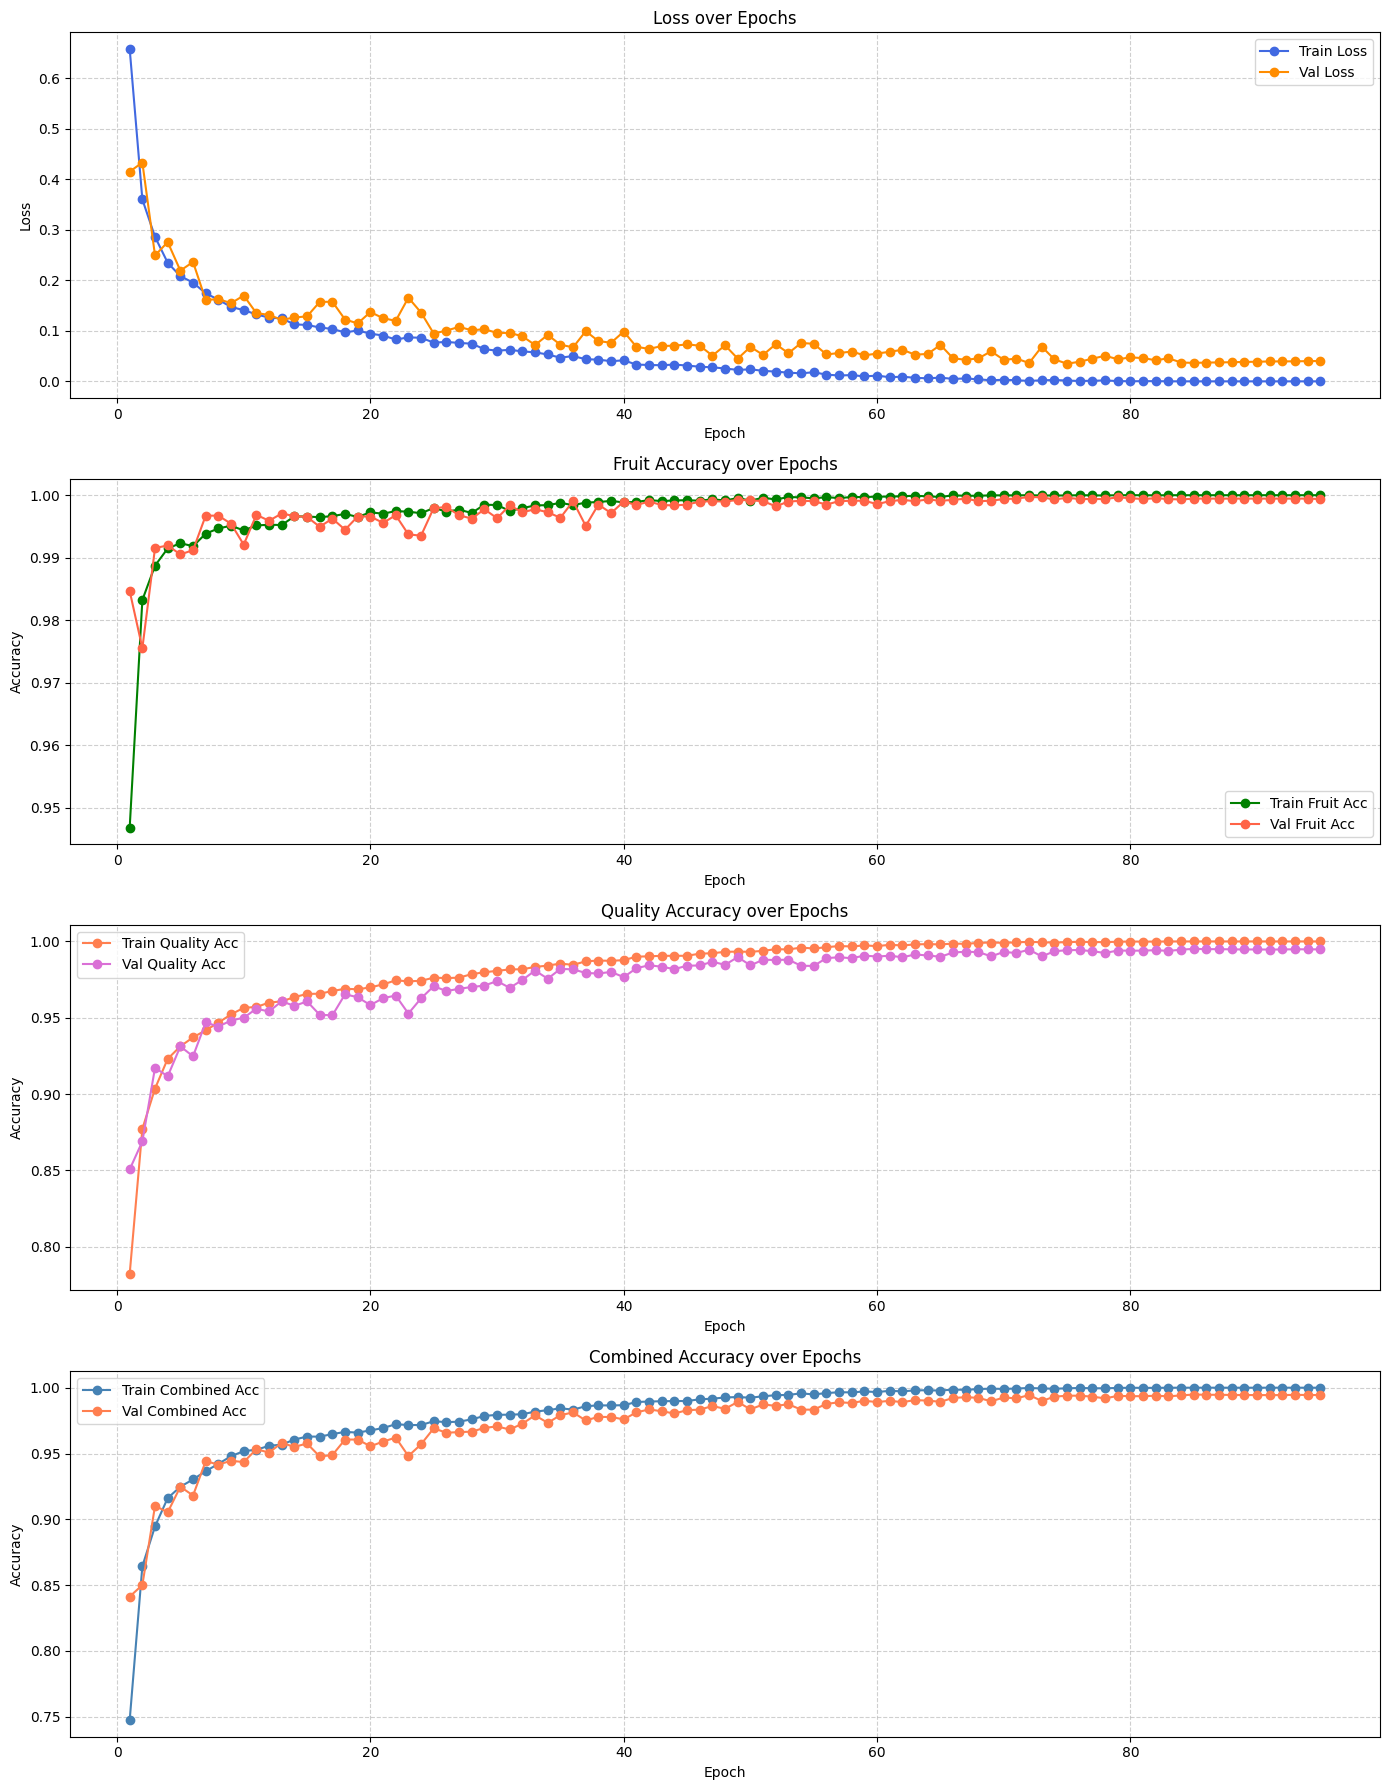

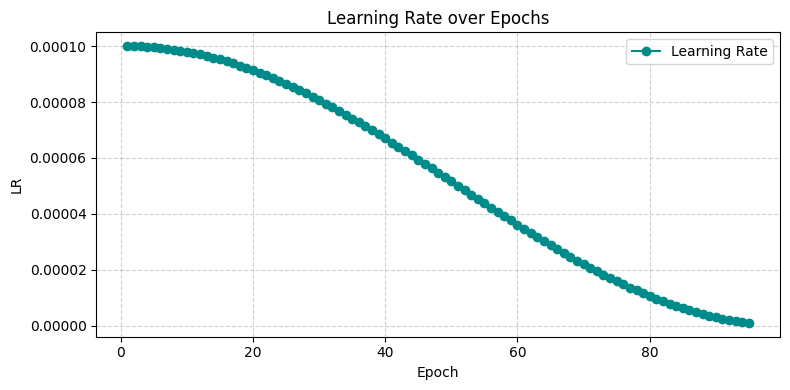

In [8]:
def plot_metrics_from_history(history):
    epochs = list(range(1, len(history['train_loss']) + 1))

    plt.figure(figsize=(14, 18))

    # Plot 1: Loss
    plt.subplot(4, 1, 1)
    plt.plot(epochs, history['train_loss'], label="Train Loss", marker='o', color='royalblue')
    plt.plot(epochs, history['val_loss'], label="Val Loss", marker='o', color='darkorange')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot 2: Fruit Accuracy
    plt.subplot(4, 1, 2)
    plt.plot(epochs, history['train_fruit_acc'], label="Train Fruit Acc", marker='o', color='green')
    plt.plot(epochs, history['val_fruit_acc'], label="Val Fruit Acc", marker='o', color='tomato')
    plt.title("Fruit Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot 3: Quality Accuracy
    plt.subplot(4, 1, 3)
    plt.plot(epochs, history['train_qual_acc'], label="Train Quality Acc", marker='o', color='coral')
    plt.plot(epochs, history['val_qual_acc'], label="Val Quality Acc", marker='o', color='orchid')
    plt.title("Quality Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot 4: Combined Accuracy
    plt.subplot(4, 1, 4)
    plt.plot(epochs, history['train_combined_acc'], label="Train Combined Acc", marker='o', color='steelblue')
    plt.plot(epochs, history['val_combined_acc'], label="Val Combined Acc", marker='o', color='coral')
    plt.title("Combined Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show() # Show the main accuracy/loss plots

    plt.figure(figsize=(8, 4)) # Create a new figure for the LR plot
    plt.plot(epochs, history['lr'], label="Learning Rate", marker='o', color='darkcyan')
    plt.title("Learning Rate over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_metrics_from_history(history)



In [9]:
def evaluate(model, loader):
    model.eval()
    all_fruit_preds = []
    all_qual_preds = []
    all_fruit_labels = []
    all_qual_labels = []
    
    with torch.no_grad():
        for images, fruit_labels, qual_labels in loader:
            images = images.to(device)
            fruit_labels = fruit_labels.to(device)
            qual_labels = qual_labels.to(device)
            
            fruit_out, qual_out = model(images)
            _, fruit_preds = torch.max(fruit_out, 1)
            _, qual_preds = torch.max(qual_out, 1)
            
            all_fruit_preds.extend(fruit_preds.cpu().numpy())
            all_qual_preds.extend(qual_preds.cpu().numpy())
            all_fruit_labels.extend(fruit_labels.cpu().numpy())
            all_qual_labels.extend(qual_labels.cpu().numpy())
    
    return all_fruit_preds, all_qual_preds, all_fruit_labels, all_qual_labels

fruit_preds, qual_preds, fruit_labels, qual_labels = evaluate(model, test_loader)

Starting inference on the test set...


Inference: 100%|█████████████████████████████████████████████████████████████████████| 459/459 [05:32<00:00,  1.38it/s]



--- Model Metrics ---
Model Size (Trainable Parameters): 85,804,808
Model Size (MB): 327.32 MB
Total Training Time: Not available (ensure train_model returns this value and it's captured).
Average Inference Time per Batch: 0.1679 seconds
Average Inference Time per Image: 0.005245 seconds

Overall Test Accuracy (Fruit Type): 0.9993
Overall Test Accuracy (Quality Type): 0.9943

--- Fruit Classification Report ---
              precision    recall  f1-score   support

       Apple     1.0000    0.9971    0.9985      1713
      Banana     0.9991    0.9994    0.9992      3267
       Grape     1.0000    1.0000    1.0000      3191
       Mango     0.9991    0.9994    0.9992      3164
      Orange     0.9988    0.9997    0.9993      3344

    accuracy                         0.9993     14679
   macro avg     0.9994    0.9991    0.9992     14679
weighted avg     0.9993    0.9993    0.9993     14679


--- Quality Classification Report ---
                precision    recall  f1-score   support


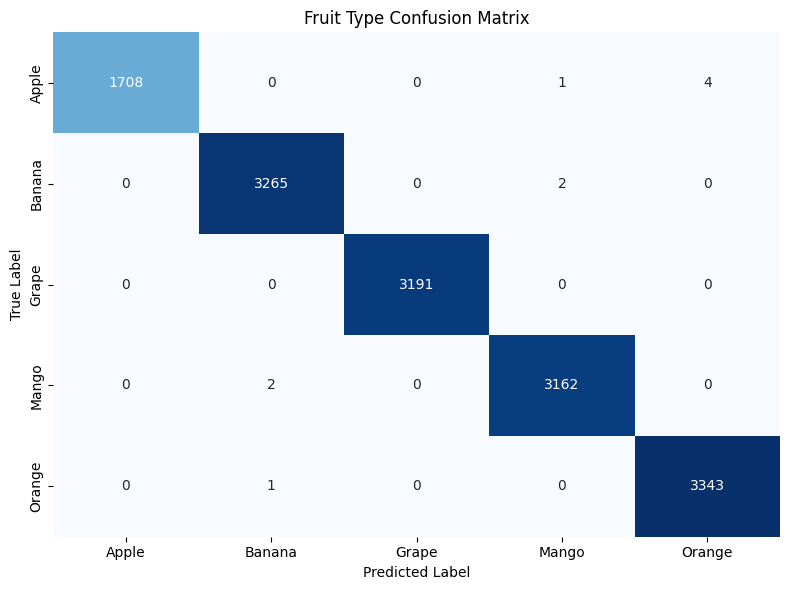


--- Quality Confusion Matrix ---
[[5955    6   10]
 [  24 4197   12]
 [  19   13 4443]]


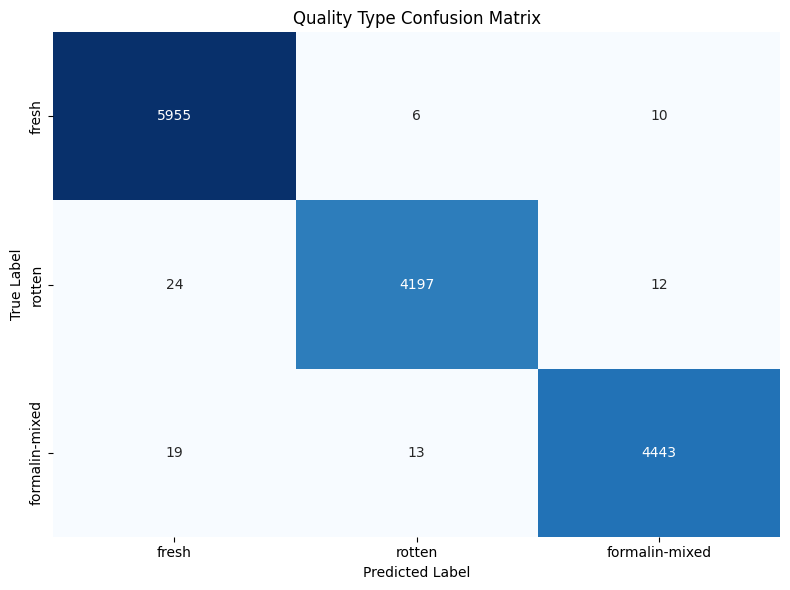


--- Fruit ROC AUC (One-vs-Rest) ---
  Apple: 1.0000
  Banana: 1.0000
  Grape: 1.0000
  Mango: 1.0000
  Orange: 1.0000

--- Quality ROC AUC (One-vs-Rest) ---
  fresh: 0.9998
  rotten: 0.9998
  formalin-mixed: 0.9999

Evaluation complete.


In [10]:
import torch
import torch.nn as nn
import time
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns # Recommended for plotting confusion matrices

# --- Assumed Global Variables / Passed-in Objects ---
# model: Your trained PyTorch model instance (after best weights are loaded)
# test_loader: Your PyTorch DataLoader for the test dataset
# device: The device ('cuda' or 'cpu') the model is on
# full_dataset: An object/class that contains .fruit_classes and .quality_classes
#               (e.g., full_dataset.fruit_classes = ['Apple', 'Banana', ...])
# total_training_time_seconds: This variable should be available from the return of your train_model function.
#                              e.g., history, total_training_time_seconds = train_model(...)


# --- 1. Helper Function to Get Model Size ---
def get_model_parameters(model):
    """Calculates the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- 2. Evaluation Function to Collect Predictions, Probabilities, and Inference Times ---
def evaluate_and_collect_data(model, loader, device):
    """
    Evaluates the model on a given loader, collecting true labels, predictions,
    probabilities, and inference times.

    Args:
        model (torch.nn.Module): The trained neural network model.
        loader (torch.utils.data.DataLoader): DataLoader for the dataset to evaluate.
        device (torch.device): The device the model is on.

    Returns:
        tuple: (all_fruit_preds, all_qual_preds, all_fruit_labels, all_qual_labels,
                all_fruit_probs, all_qual_probs, inference_times_per_batch)
    """
    model.eval() # Set the model to evaluation mode
    all_fruit_preds = []
    all_qual_preds = []
    all_fruit_labels = []
    all_qual_labels = []
    all_fruit_probs = [] # To store softmax probabilities for ROC AUC
    all_qual_probs = []  # To store softmax probabilities for ROC AUC
    inference_times_per_batch = [] # List to store inference time for each batch

    print("Starting inference on the test set...")
    with torch.no_grad(): # Disable gradient calculations for inference
        for images, fruit_labels_batch, qual_labels_batch in tqdm(loader, desc="Inference"):
            images = images.to(device)

            # Measure inference time for the current batch
            start_time = time.time()
            fruit_out, qual_out = model(images)
            if device.type == 'cuda':
                torch.cuda.synchronize() # Ensure all CUDA operations are complete before stopping the timer
            end_time = time.time()

            inference_times_per_batch.append(end_time - start_time)

            # Get hard predictions (class indices)
            _, fruit_preds_batch = torch.max(fruit_out, 1)
            _, qual_preds_batch = torch.max(qual_out, 1)

            # Get probabilities (softmax outputs) for ROC AUC
            # Ensure the output is logits before applying softmax if your model doesn't do it internally
            fruit_probs_batch = torch.softmax(fruit_out, dim=1)
            qual_probs_batch = torch.softmax(qual_out, dim=1)

            # Store labels, predictions, and probabilities (move to CPU and convert to numpy)
            all_fruit_labels.extend(fruit_labels_batch.cpu().numpy())
            all_fruit_preds.extend(fruit_preds_batch.cpu().numpy())
            all_fruit_probs.extend(fruit_probs_batch.cpu().numpy())

            all_qual_labels.extend(qual_labels_batch.cpu().numpy())
            all_qual_preds.extend(qual_preds_batch.cpu().numpy())
            all_qual_probs.extend(qual_probs_batch.cpu().numpy())

    return (all_fruit_preds, all_qual_preds, all_fruit_labels, all_qual_labels,
            all_fruit_probs, all_qual_probs, inference_times_per_batch)


# --- Execute Evaluation and Collect Data ---
(fruit_preds, qual_preds, fruit_labels, qual_labels,
 fruit_probs, qual_probs, inference_times) = evaluate_and_collect_data(model, test_loader, device)

print("\n--- Model Metrics ---")

# --- Report Model Size (Parameters and MB) ---
model_parameters = get_model_parameters(model)
model_size_bytes = model_parameters * 4  # Assuming float32 (4 bytes per parameter)
model_size_mb = model_size_bytes / (1024 * 1024)

print(f"Model Size (Trainable Parameters): {model_parameters:,}")
print(f"Model Size (MB): {model_size_mb:.2f} MB")


# --- Report Total Training Time ---
# This variable 'total_training_time_seconds' should be returned by your train_model function.
# For example: history, total_training_time_seconds = train_model(...)
if 'total_training_time_seconds' in locals() or 'total_training_time_seconds' in globals():
    print(f"Total Training Time: {total_training_time_seconds:.2f} seconds ({total_training_time_seconds / 3600:.2f} hours)")
else:
    print("Total Training Time: Not available (ensure train_model returns this value and it's captured).")


# --- Report Inference Time ---
if inference_times:
    avg_inference_time_per_batch = sum(inference_times) / len(inference_times)
    print(f"Average Inference Time per Batch: {avg_inference_time_per_batch:.4f} seconds")
    if test_loader and test_loader.batch_size > 0:
        avg_inference_time_per_image = avg_inference_time_per_batch / test_loader.batch_size
        print(f"Average Inference Time per Image: {avg_inference_time_per_image:.6f} seconds")
else:
    print("No batches processed for inference time calculation.")


# --- Get Class Names (assuming full_dataset has these attributes) ---
fruit_classes = full_dataset.fruit_classes
qual_classes = full_dataset.quality_classes


# --- Report Overall Accuracies ---
fruit_accuracy = accuracy_score(fruit_labels, fruit_preds)
qual_accuracy = accuracy_score(qual_labels, qual_preds)
print(f"\nOverall Test Accuracy (Fruit Type): {fruit_accuracy:.4f}")
print(f"Overall Test Accuracy (Quality Type): {qual_accuracy:.4f}")


# --- Print Classification Reports (Precision, Recall, F1-score, Support) ---
print("\n--- Fruit Classification Report ---")
print(classification_report(fruit_labels, fruit_preds, target_names=fruit_classes, digits=4))

print("\n--- Quality Classification Report ---")
print(classification_report(qual_labels, qual_preds, target_names=qual_classes, digits=4))


# --- Plot and Print Confusion Matrices ---
print("\n--- Fruit Confusion Matrix ---")
fruit_cm = confusion_matrix(fruit_labels, fruit_preds)
print(fruit_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(fruit_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=fruit_classes, yticklabels=fruit_classes, cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Fruit Type Confusion Matrix')
plt.tight_layout()
plt.show()


print("\n--- Quality Confusion Matrix ---")
qual_cm = confusion_matrix(qual_labels, qual_preds)
print(qual_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(qual_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=qual_classes, yticklabels=qual_classes, cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Quality Type Confusion Matrix')
plt.tight_layout()
plt.show()


# --- Calculate and Print ROC AUC for Each Class (One-vs-Rest) ---

# For Fruit Type
print("\n--- Fruit ROC AUC (One-vs-Rest) ---")
# Binarize the true labels for multi-class ROC AUC calculation
fruit_labels_binarized = label_binarize(fruit_labels, classes=np.arange(len(fruit_classes)))
fruit_auc_scores = {}
for i, class_name in enumerate(fruit_classes):
    try:
        # Check if there's at least one positive and one negative sample for the class
        if len(np.unique(fruit_labels_binarized[:, i])) > 1:
            auc = roc_auc_score(fruit_labels_binarized[:, i], np.array(fruit_probs)[:, i])
            fruit_auc_scores[class_name] = auc
            print(f"  {class_name}: {auc:.4f}")
        else:
            print(f"  {class_name}: Not enough samples of both classes to compute AUC (requires at least two unique labels).")
            fruit_auc_scores[class_name] = np.nan # Append NaN if AUC cannot be computed
    except ValueError as e:
        print(f"  {class_name}: Error computing AUC - {e}")
        fruit_auc_scores[class_name] = np.nan


# For Quality Type (CRITICAL for formalin-mixed analysis)
print("\n--- Quality ROC AUC (One-vs-Rest) ---")
qual_labels_binarized = label_binarize(qual_labels, classes=np.arange(len(qual_classes)))
qual_auc_scores = {}
for i, class_name in enumerate(qual_classes):
    try:
        if len(np.unique(qual_labels_binarized[:, i])) > 1:
            auc = roc_auc_score(qual_labels_binarized[:, i], np.array(qual_probs)[:, i])
            qual_auc_scores[class_name] = auc
            print(f"  {class_name}: {auc:.4f}")
        else:
            print(f"  {class_name}: Not enough samples of both classes to compute AUC (requires at least two unique labels).")
            qual_auc_scores[class_name] = np.nan
    except ValueError as e:
        print(f"  {class_name}: Error computing AUC - {e}")
        qual_auc_scores[class_name] = np.nan

print("\nEvaluation complete.")


In [11]:
def compute_per_class_accuracy(true_labels, pred_labels, class_names):
    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)
    print(f"\nPer-Class Accuracy:")
    for i, cls in enumerate(class_names):
        idxs = np.where(true_labels == i)[0]
        correct = np.sum(true_labels[idxs] == pred_labels[idxs])
        total = len(idxs)
        acc = correct / total if total > 0 else 0
        print(f"{cls:25s}: {acc*100:.2f}% ({correct}/{total})")

compute_per_class_accuracy(fruit_labels, fruit_preds, fruit_classes)
compute_per_class_accuracy(qual_labels, qual_preds, qual_classes)


Per-Class Accuracy:
Apple                    : 99.71% (1708/1713)
Banana                   : 99.94% (3265/3267)
Grape                    : 100.00% (3191/3191)
Mango                    : 99.94% (3162/3164)
Orange                   : 99.97% (3343/3344)

Per-Class Accuracy:
fresh                    : 99.73% (5955/5971)
rotten                   : 99.15% (4197/4233)
formalin-mixed           : 99.28% (4443/4475)


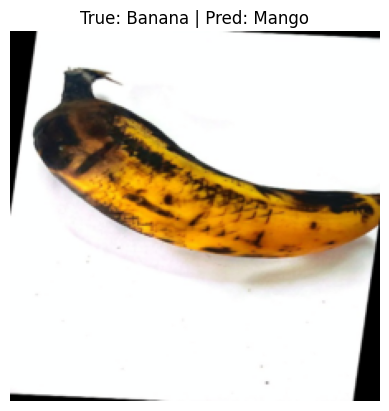

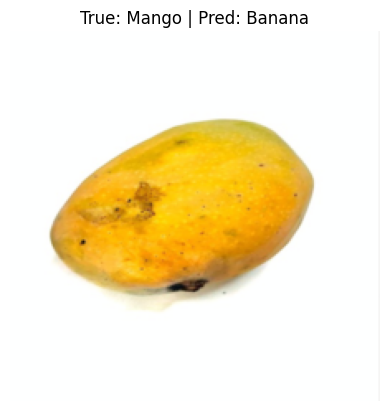

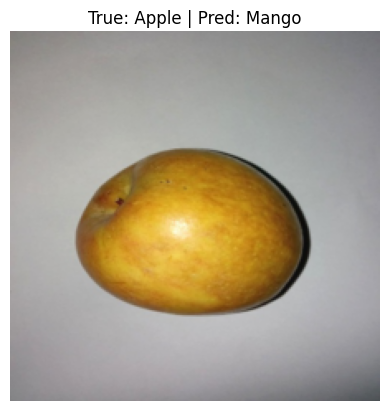

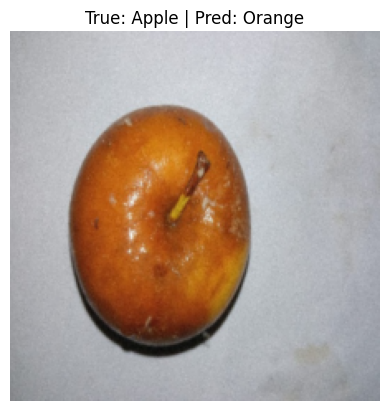

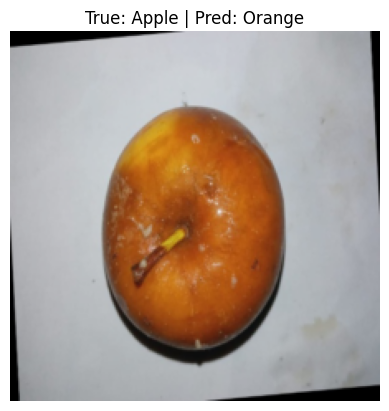

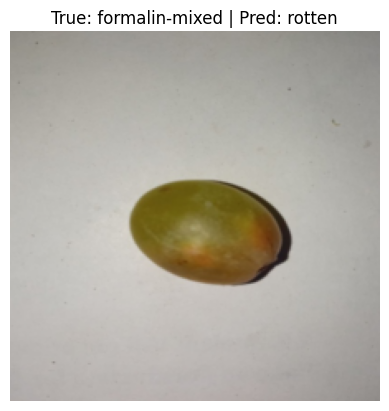

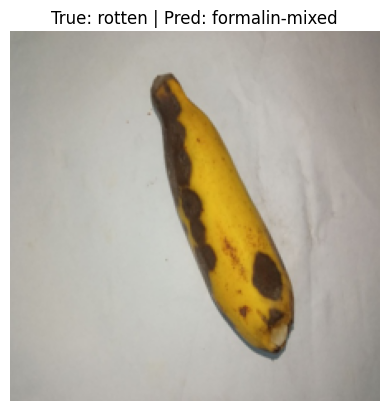

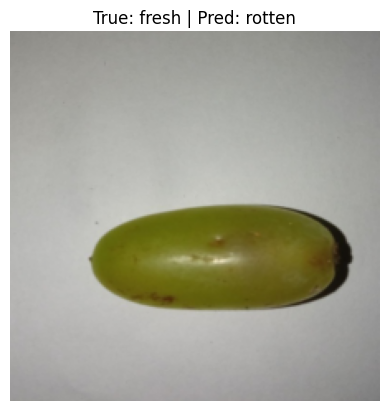

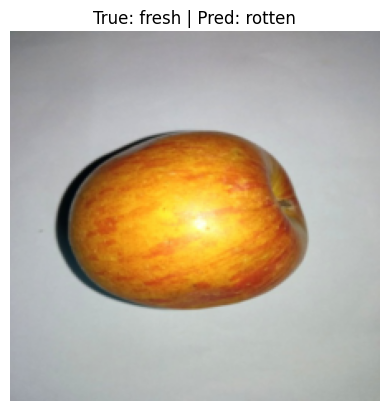

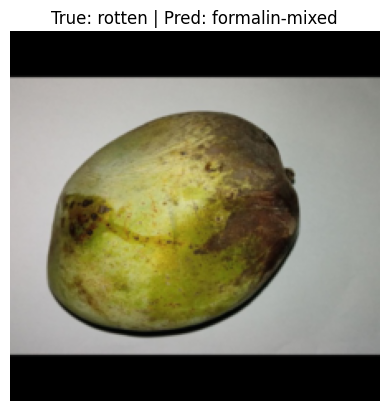

In [12]:
def show_misclassified_images(model, dataset, loader, class_names, mode='fruit', max_images=5):
    model.eval()
    shown = 0
    
    with torch.no_grad():
        for images, fruit_labels, qual_labels in loader:
            images = images.to(device)
            fruit_labels = fruit_labels.to(device)
            qual_labels = qual_labels.to(device)
            
            fruit_out, qual_out = model(images)
            _, fruit_preds = torch.max(fruit_out, 1)
            _, qual_preds = torch.max(qual_out, 1)
            
            for i in range(images.size(0)):
                if (mode == 'fruit' and fruit_preds[i] != fruit_labels[i]) or (mode == 'qual' and qual_preds[i] != qual_labels[i]):
                    img_np = images[i].cpu().permute(1, 2, 0).numpy()
                    img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)
                    plt.imshow(img_np)
                    plt.axis('off')
                    
                    if mode == 'fruit':
                        plt.title(f"True: {class_names[fruit_labels[i]]} | Pred: {class_names[fruit_preds[i]]}")
                    else:
                        plt.title(f"True: {class_names[qual_labels[i]]} | Pred: {class_names[qual_preds[i]]}")
                    
                    plt.show()
                    shown += 1
                    if shown >= max_images:
                        return

show_misclassified_images(model, full_dataset, test_loader, fruit_classes, mode='fruit', max_images=5)
show_misclassified_images(model, full_dataset, test_loader, qual_classes, mode='qual', max_images=5)

In [13]:
def analyze_confidences(model, loader, class_names, mode='fruit', top_k=5):
    model.eval()
    confidences = []
    class_conf_sum = [0.0] * len(class_names)
    class_conf_count = [0] * len(class_names)

    with torch.no_grad():
        for images, fruit_labels, qual_labels in loader:
            images = images.to(device)
            fruit_out, qual_out = model(images)

            if mode == 'fruit':
                probs = torch.softmax(fruit_out, dim=1)
                preds = torch.argmax(probs, dim=1)
                labels = fruit_labels
            else:
                probs = torch.softmax(qual_out, dim=1)
                preds = torch.argmax(probs, dim=1)
                labels = qual_labels

            for i in range(images.size(0)):
                confidence = probs[i][preds[i]].item()
                correct = preds[i] == labels[i]
                pred_class = preds[i].item()
                true_class = labels[i].item()
                confidences.append((confidence, correct, pred_class, true_class, images[i]))

                # Accumulate confidence for per-class average
                class_conf_sum[true_class] += confidence
                class_conf_count[true_class] += 1

    # Sort for analysis
    correct_preds = [c for c in confidences if c[1]]
    incorrect_preds = [c for c in confidences if not c[1]]
    
    correct_preds.sort(key=lambda x: x[0])  # least confident correct
    incorrect_preds.sort(key=lambda x: x[0], reverse=True)  # most confident incorrect

    print(f"\n🔍 Top {top_k} Least Confident Correct Predictions ({mode}):")
    for i in range(min(top_k, len(correct_preds))):
        conf, _, pred, true, _ = correct_preds[i]
        print(f"✓ Pred: {class_names[pred]:20s} | True: {class_names[true]:20s} | Confidence: {conf:.4f}")

    print(f"\n⚠️ Top {top_k} Most Confident Incorrect Predictions ({mode}):")
    for i in range(min(top_k, len(incorrect_preds))):
        conf, _, pred, true, _ = incorrect_preds[i]
        print(f"✗ Pred: {class_names[pred]:20s} | True: {class_names[true]:20s} | Confidence: {conf:.4f}")

    print(f"\n📊 Per-Class Average Confidence ({mode}):")
    for idx, (total, count) in enumerate(zip(class_conf_sum, class_conf_count)):
        avg_conf = total / count if count > 0 else 0.0
        print(f"- {class_names[idx]:20s}: {avg_conf:.4f} over {count} samples")
analyze_confidences(model, test_loader, fruit_classes, mode='fruit', top_k=5)
analyze_confidences(model, test_loader, qual_classes, mode='qual', top_k=5)



🔍 Top 5 Least Confident Correct Predictions (fruit):
✓ Pred: Apple                | True: Apple                | Confidence: 0.8182
✓ Pred: Mango                | True: Mango                | Confidence: 0.8524
✓ Pred: Apple                | True: Apple                | Confidence: 0.9043
✓ Pred: Banana               | True: Banana               | Confidence: 0.9657
✓ Pred: Apple                | True: Apple                | Confidence: 0.9673

⚠️ Top 5 Most Confident Incorrect Predictions (fruit):
✗ Pred: Banana               | True: Orange               | Confidence: 1.0000
✗ Pred: Orange               | True: Apple                | Confidence: 1.0000
✗ Pred: Orange               | True: Apple                | Confidence: 1.0000
✗ Pred: Banana               | True: Mango                | Confidence: 0.9993
✗ Pred: Orange               | True: Apple                | Confidence: 0.9992

📊 Per-Class Average Confidence (fruit):
- Apple               : 0.9998 over 1713 samples
- Banana  